Sample Data:
    Soil_Nitrogen    Rainfall  Temperature  Water_Usage  Label
0      74.967142  632.408397    17.923146   420.039428      1
1      68.617357  561.491772    22.896773   427.715857      1
2      76.476885  532.307800    23.286427   345.598022      0
3      85.230299  661.167629    20.988614   418.580296      1
4      67.658466  703.099952    24.193571   423.445798      1
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7250 - loss: 0.6201
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7250 - loss: 0.6121
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7500 - loss: 0.6055 
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7500 - loss: 0.5995 
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7750 - loss: 0.5930 
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7750 - loss: 0.5866 
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7750 - loss: 0.5808 
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7750 - loss: 0.5745
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7750 - loss: 0.5691 
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7750 - loss: 0.5629
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7750 - loss: 0.5572 
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7750 - loss: 0.5512 
Epoch 13/50


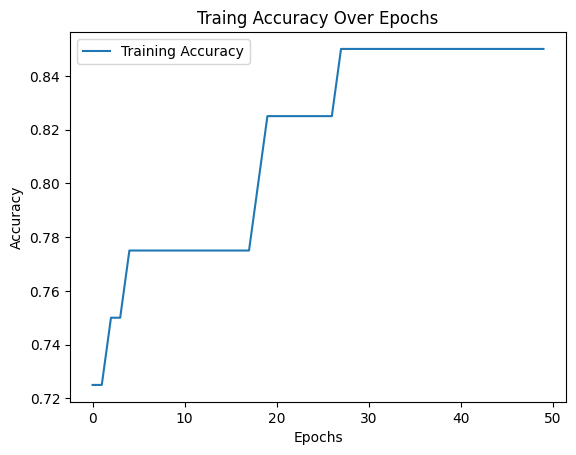

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Step 1 Geenrate Dataset(50 samples)

np.random.seed(42)
n_samples=50

data=pd.DataFrame({"Soil_Nitrogen":np.random.normal(70,10,n_samples),
                   "Rainfall":np.random.normal(600,100,n_samples),
                   "Temperature":np.random.normal(25,5,n_samples),
                   "Water_Usage":np.random.normal(400,80,n_samples)})

#Create classification label (Healthy=1,unhealthy=0)
data["Label"] = ((data["Soil_Nitrogen"]>65)&(data["Rainfall"]>550)&(data["Water_Usage"]>350)).astype(int)
print("Sample Data:\n",data.head())

# Split features and labels
X=data.drop("Label",axis=1)
y=data["Label"]

# Traina and test split
X_Train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# feature sCaling
scaler=StandardScaler()
X_train=scaler.fit_transform(X_Train)
X_test=scaler.transform(X_test)

# 5 Build ANN model
model=Sequential()
# Input+ Hidden layers
model.add(Dense(8,activation="relu",input_dim=X_train.shape[1]))
model.add(Dense(6,activation="relu"))

# output layer(Binary classification)
model.add(Dense(1,activation="sigmoid"))

# Compile model
model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])


# Train model
history=model.fit(X_train,y_train,epochs=50,batch_size=5,verbose=1)


# 8 prediction
y_pred=model.predict(X_test)
y_pred=(y_pred>0.5).astype(int)

# 9 evaluation matrix
print("----- model evaluation----")
accuracy=accuracy_score(y_test,y_pred)

print("Accuracy:",accuracy)

print("\n Confusion matrix:\n",confusion_matrix(y_test,y_pred))
print("\n Classification Report:\n",classification_report(y_test,y_pred))

# 10 Plot training performance

plt.figure()
plt.plot(history.history["accuracy"],label="Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Traing Accuracy Over Epochs")
plt.legend()
plt.show()